# Genetic algorithm demo

In [2]:
%matplotlib widget

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import animation, rc
rc("animation", html="html5")
from math import cos, pi
import itertools
import numpy as np
import ipywidgets as widgets
from ipywidgets import interact_manual


In [3]:
def cost(x):
    return x**2 / 10 - np.cos(2* pi * x) + 1

In [4]:
xg = np.linspace(-5., 5., 500)
yg = cost(xg)

In [5]:
class Genetic:
    """
    A genetic algorithm class.
    """
    def __init__(self, func, xv, keep_ratio = 0.2, mut_ratio = 0.2, mut_sigma =  2):
        self.func = func
        self.xv = xv
        self.keep_ratio = keep_ratio
        self.mut_ratio = mut_ratio
        self.mut_sigma = mut_sigma
        self.generation = 0
    
    def get_y(self):
        return self.func(self.xv)
    
    y = property(get_y)
    
    def sort_by_fitness(self):
        xv = self.xv
        yv = self.y
        order = np.argsort(yv)
        xv = xv[order]
        #yv = yv[order]
        self.xv = xv
    
    def best_individual(self):
        self.sort_by_fitness()
        return self.xv[0], self.y[0]
    
    def evolve(self):
        self.sort_by_fitness()
        xv = self.xv
        keep_ratio = self.keep_ratio
        mut_ratio = self.mut_ratio
        mut_sigma = self.mut_sigma
        yv = self.y
        #order = np.argsort(yv)
        #xv = xv[order]
        #yv = yv[order]
        new_xv = np.zeros_like(xv)
        # KEEP THE FITTEST
        nx = xv.size
        xpos = np.linspace(0., 1., nx) 
        keep_pos = xpos <= keep_ratio
        nk = keep_pos.sum()
        # HYBRIDATION
        rng = np.random.default_rng()
        parents_pool = list(itertools.combinations(xv[:nk],2))
        new_xv[:nk] = xv[:nk]
        parents_list = [parents_pool[i] for i in np.random.randint(low=0,high=len(parents_pool),size=len(new_xv)-nk)]
        for index,parents in enumerate(parents_list):
            eps = rng.random()
            child = (parents[0]*(1+eps)+parents[1]*(1-eps))/2
            if rng.random()<mut_ratio:
                #child+= (rng.random()-0.5)*2*mut_sigma**2
                child += np.random.normal(loc = 0., scale = mut_sigma)
            new_xv[nk:][index] = child
        
        # STORAGE
        self.xv = new_xv 
        # GENERATION UPDATE
        self.generation += 1
        
        

interactive(children=(FloatSlider(value=0.1, description='mut_sigma', max=1.0, step=0.01), FloatSlider(value=0…

<function __main__.update(mut_sigma=0.1, keep_ratio=0.2)>

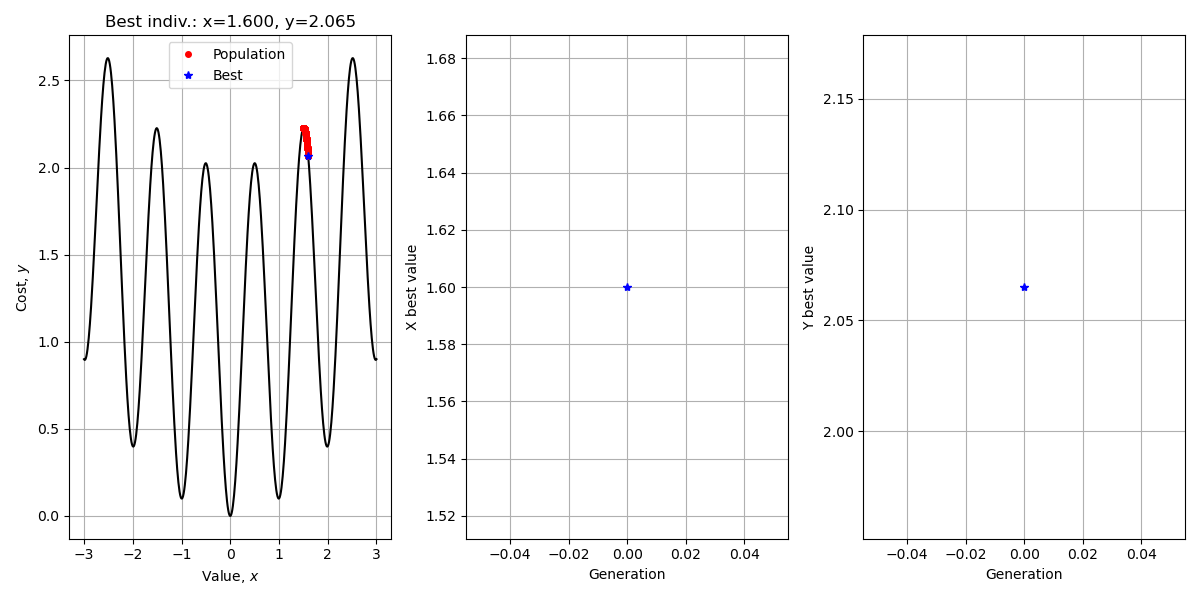

In [ ]:

xg = np.linspace(-3., 3., 500)
yg = cost(xg)



xv = np.linspace(1.5, 1.6, 500)
population = Genetic(cost, xv)
generations = [0]
xb, yb = population.best_individual()
xbs = [xb]
ybs = [yb]

fig = plt.figure(figsize = (8,4))
ax = fig.add_subplot(131)
plt.plot(xg, yg, "k-")
scat, = plt.plot(xv,cost(xv),"or", ms =4., label = "Population")
xb, yb = population.best_individual()
scat2, = plt.plot([xb],[yb],"b*", ms =6., label = "Best")
plt.xlabel("Value, $x$")
plt.ylabel("Cost, $y$")
title = ax.set_title("Optimization Hell")
plt.legend(loc='lower left')
plt.grid()
xb, yb = population.best_individual()
ax.set_title(f"Best indiv.: x={xb:.3f}, y={yb:.3f}")
plt.legend()
ax2 = fig.add_subplot(132)
ax2.set_xlabel("Generation")
ax2.set_ylabel("X best value")
scat3,  = plt.plot(generations, xbs, "b*-")
plt.grid()
ax3 = fig.add_subplot(133)
ax3.set_xlabel("Generation")
ax3.set_ylabel("Y best value")
scat4,  = plt.plot(generations, ybs, "b*-")
plt.grid()
plt.tight_layout()

def update(mut_sigma = 0.1, keep_ratio = 0.2):
    ax.set_title(f"fffgg{i}")
    population.mut_sigma = mut_sigma
    population.keep_ratio = keep_ratio
    population.evolve()
    generations.append(population.generation)
    a = np.array([population.xv, population.y]).T
    scat.set_data(population.xv, population.y)
    xb, yb = population.best_individual()
    ax.set_title(f"Best indiv.: x={xb:.3f}, y={yb:.3f}")
    scat2.set_data([xb],[yb])
    xbs.append(xb)
    ybs.append(yb)
    scat3.set_data(generations,xbs)
    ax2.relim()
    ax2.autoscale_view()
    scat4.set_data(generations,ybs)
    ax3.relim()
    ax3.autoscale_view()
    

widgets.interact_manual(update, mut_sigma = (0, 1, 0.01), keep_ratio = (0.1, 1., 0.01) )